#### Loading training and validation datasets

Import libraries and set directories

In [71]:
from pathlib import Path
import pickle
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter # To count the number of occurrences of each label

DATA_DIR = Path.home() / "Desktop" / "gnn_trajectory" / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

train_path = PROCESSED_DATA_DIR / "nuscenes_train_prediction_samples.pkl"
val_path = PROCESSED_DATA_DIR / "nuscenes_val_prediction_samples.pkl"

# Load dataset
with open(train_path, "rb") as f: # rb = read binary
    train_dataset = pickle.load(f)
    
with open(val_path, "rb") as f: 
    val_dataset = pickle.load(f)
    
print("Train samples: ",len(train_dataset))
print("Val samples: ",len(val_dataset))

Train samples:  25711
Val samples:  7242


#### Constant velocity baseline

For each sample we estimate the velocity from the past target. Since data is at 0.5 s intervals (2 Hz) we compute velocity as $v$ and predict 
$p_t$ as: 

$$v = \frac{p_t - p_{t-1}}{0.5} \ \ \ \ \  \hat p_t = p_{0} + v \cdot t$$

for the next **12** steps starting from $p_0$ (current position).

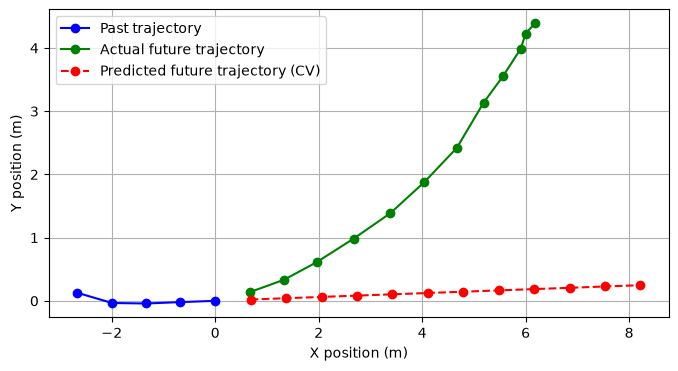

In [28]:
import numpy as np

def constant_velocity_prediction(target_past, future_steps=12, dt=0.5): 
    
    p_prev = target_past[-2] # get last 2s  
    p_current = target_past[-1] # 
    
    velocity = (p_current - p_prev) / dt  
    
    predictions = []
    
    for step in range(1, future_steps + 1):
        t = step * dt
        pred = p_current + velocity * t
        predictions.append(pred)
        
    return np.array(predictions)

sample = val_dataset[0]
y_past = sample['target_past']

# Compare y_hat and y
y_hat = constant_velocity_prediction(sample['target_past'])
y = sample['target_future']

plt.figure(figsize=(8, 4))
plt.plot(y_past[:, 0], y_past[:, 1], 'bo-', label='Past trajectory')
plt.plot(y[:, 0], y[:, 1], 'go-', label='Actual future trajectory')
plt.plot(y_hat[:, 0], y_hat[:, 1], 'ro--', label='Predicted future trajectory (CV)')
plt.xlabel('X position (m)'); plt.ylabel('Y position (m)')
plt.legend(); plt.grid()  

#### Benchmarking
For benchmarking, we compute the average displacement error (ADE) and final displacement error (FDE) for each sample in the validation set. 

```bash
- ADE will tell, on average, how far the predicted trajectory is from the ground truth trajectory.
```
```bash
- FDE tells how wrong the final 6s position is
```

\begin{equation}
ADE = \frac{1}{12} \sum_{t=1}^{12} \sqrt{(x_t - \hat{x}_t)^2 + (y_t - \hat{y}_t)^2}
\end{equation}


In [37]:
def compute_ade_fde(pred_future, target_future):
    pred_future = np.asarray(pred_future)
    target_future = np.asarray(target_future)
    errors = np.linalg.norm(pred_future - target_future, axis=1)
    return errors.mean(), errors[-1]

# Sample error
ade, fde = compute_ade_fde(y_hat, sample["target_future"])
# print("ADE:", ade)
# print("FDE:", fde)

# For all validation samples
cv_ade_list = []
cv_fde_list = []

for sample in val_dataset: 
    y_hat = constant_velocity_prediction(sample['target_past'])
    ade, fde = compute_ade_fde(y_hat, sample["target_future"])
    
    cv_ade_list.append(ade)
    cv_fde_list.append(fde)
    
# mean ADE and FDE
cv_ade_mean = np.mean(cv_ade_list)
cv_fde_mean = np.mean(cv_fde_list)

print("Validation samples:", len(val_dataset))
print("Constant Velocity Baseline - Mean ADE:", cv_ade_mean)
print("Constant Velocity Baseline - Mean FDE:", cv_fde_mean)    

Validation samples: 7242
Constant Velocity Baseline - Mean ADE: 4.6721587
Constant Velocity Baseline - Mean FDE: 11.287091


- On average, across all 12 future points, CV is about 4.67 m away from the true trajectory.
- At the final 6-second point, it is about 11.29 m away

#### Prepare data for GNN 

Check Notion page  [here](https://good-bluebell-9e8.notion.site/NuScenes-data-3e61be03c31580a5b85ce80655d3947c?source=copy_link) for more information about the data strucuture and how to prepare it for GNN training.

Target past shape: (5, 2)
Target future shape: (12, 2)
Number of neighbors: 8
Number of Nodes: 9
Neighbor 0: (5, 2) vehicle.truck
Neighbor 1: (5, 2) vehicle.car
Neighbor 2: (5, 2) vehicle.truck
Neighbor 3: (5, 2) vehicle.car
Neighbor 4: (5, 2) vehicle.truck
Neighbor 5: (5, 2) vehicle.car
Neighbor 6: (5, 2) vehicle.truck
Neighbor 7: (5, 2) vehicle.car

Metadata split: v1.0-trainval
Scene token: bebf5f5b2a674631ab5c88fd1aa9e87a
Camera images for this sample:
CAM_BACK: /home/danilo/Desktop/gnn_trajectory/data/sweeps/CAM_BACK/n008-2018-08-27-11-48-51-0400__CAM_BACK__1535385094387558.jpg (valid image)
CAM_BACK_LEFT: /home/danilo/Desktop/gnn_trajectory/data/sweeps/CAM_BACK_LEFT/n008-2018-08-27-11-48-51-0400__CAM_BACK_LEFT__1535385094297405.jpg (valid image)
CAM_BACK_RIGHT: /home/danilo/Desktop/gnn_trajectory/data/samples/CAM_BACK_RIGHT/n008-2018-08-27-11-48-51-0400__CAM_BACK_RIGHT__1535385094528113.jpg (valid image)
CAM_FRONT: /home/danilo/Desktop/gnn_trajectory/data/sweeps/CAM_FRONT/n008-20

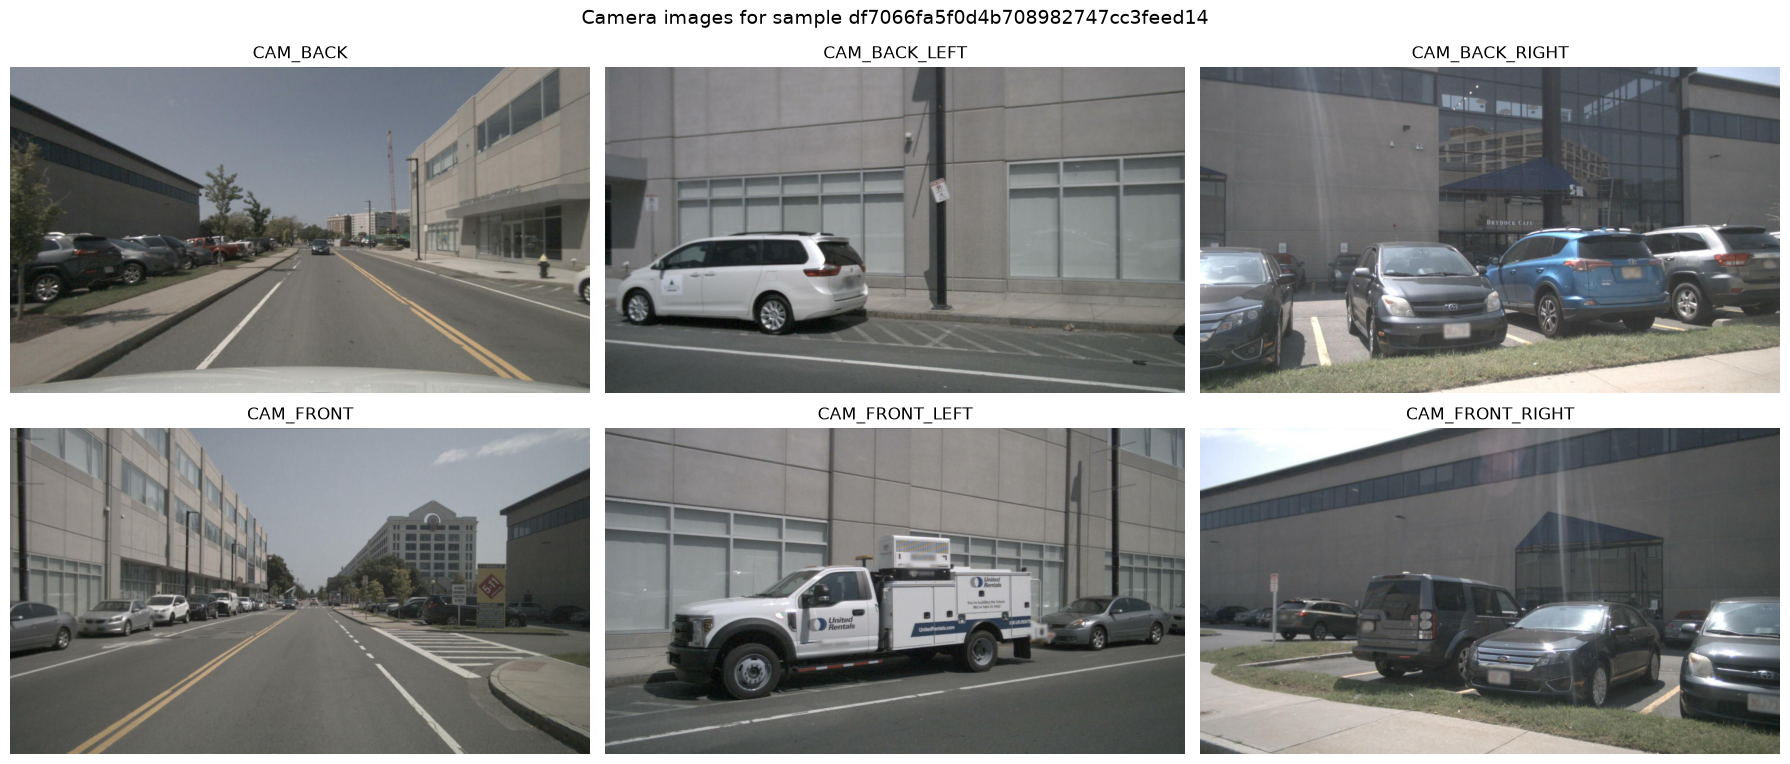

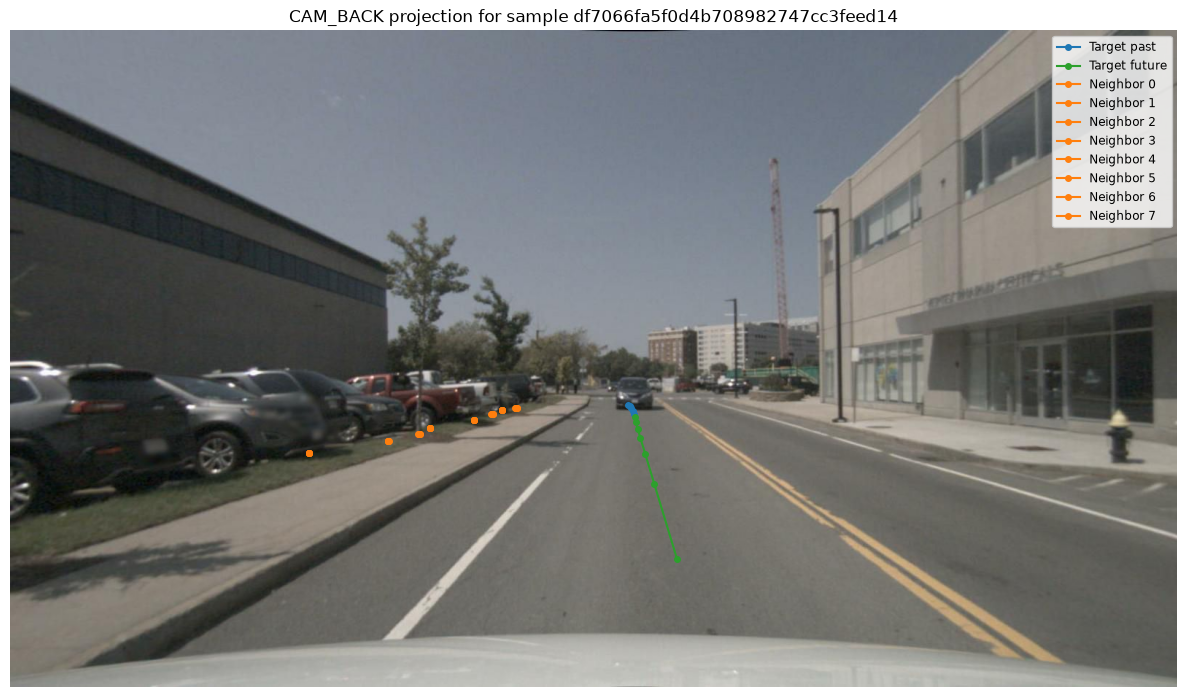

(<Figure size 1200x700 with 1 Axes>,
 <Axes: title={'center': 'CAM_BACK projection for sample df7066fa5f0d4b708982747cc3feed14'}>)

In [ ]:
sample = train_dataset[8842]

print("Target past shape:", sample["target_past"].shape)
print("Target future shape:", sample["target_future"].shape)
print("Number of neighbors:", len(sample["neighbors_pasts"]))
print("Number of Nodes:", len(sample["neighbors_pasts"]) + 1) # +1 for target node

for i, (past, category) in enumerate(zip(
    sample["neighbors_pasts"],sample["neighbors_categories"])):
    print(f"Neighbor {i}:",past.shape,category)
   
print()

# Visualize all camera images and project onto the camera facing the target
import sys

sys.path.insert(0, str(DATA_DIR.parent / "scripts"))
from view_sample_image import view_sample_images
from project_sample_to_camera import plot_sample_camera_projection

view_sample_images(sample, DATA_DIR)
plot_sample_camera_projection(sample, DATA_DIR, channel="CAM_BACK")

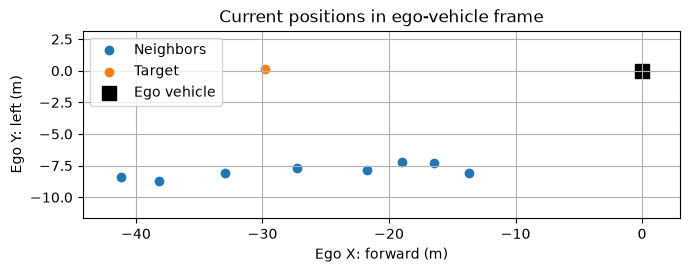

(<Figure size 700x600 with 1 Axes>,
 <Axes: title={'center': 'Current positions in ego-vehicle frame'}, xlabel='Ego X: forward (m)', ylabel='Ego Y: left (m)'>)

In [124]:
import sys
import importlib

sys.path.insert(0, str(DATA_DIR.parent / "scripts"))
import project_sample_to_camera
importlib.reload(project_sample_to_camera)

project_sample_to_camera.plot_sample_ego_frame(sample, DATA_DIR)

**Coordinate-frame note**: The nuScenes camera images are captured from the ego vehicle, i.e. the sensor-equipped data-collection car. The trajectory-prediction target is a separate annotated road user. Our trajectory plots are transformed into the target vehicle's local frame, where the target is located at \((0,0)\). Therefore, the origin of the trajectory plot does not correspond to the camera/ego vehicle. The same target may, for example, lie behind the ego vehicle and consequently appear in `CAM_BACK`